# Thevenin (voltage) source vs. current source

`groundinsight` historically models a fault as an ideal current source: a fixed phasor `I_src(f)` is injected at the source bus and an equal amount is drawn at the fault bus. This is the right abstraction for stationary grounding planning, where the prospective fault current is treated as an external input.

For transient simulations this is no longer accurate. The fault current builds up and decays through a finite source impedance (transformer, phase conductor, neutral grounding, fault arc). To express that, the `Source` model now supports a Thevenin variant that is opt-in via `source_type="voltage"` (or the convenience factory `gi.create_voltage_source`).

This notebook does three things:

1. Confirm that a Thevenin source with very large `Z_src` reproduces the legacy current-source result.
2. Show how a finite `Z_src` reduces the effective fault current relative to the open-circuit Norton value.
3. Sweep `Z_src` and visualise the transition between the two limits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import groundinsight as gi
from groundinsight.models.core_models import BusType, BranchType

# Frequency-independent toy network so the analytic comparison stays simple.
BUS_TYPE = BusType(
    name="BT_const",
    description="10 ohm grounding impedance",
    system_type="Substation",
    voltage_level=20.0,
    impedance_formula="rho * 0 + 10 + I * f * 0",
)
BRANCH_TYPE = BranchType(
    name="BR_const",
    description="1 ohm self / 0.2 ohm mutual per length",
    grounding_conductor=True,
    self_impedance_formula="(rho * 0 + 1.0 + I * f * 0) * l",
    mutual_impedance_formula="(rho * 0 + 0.2 + I * f * 0) * l",
)


def build_two_bus_network(name):
    """Two-bus network with one connecting branch and a fault at bus2."""
    net = gi.create_network(name=name, frequencies=[50])
    gi.create_bus(name="bus1", type=BUS_TYPE, network=net)
    gi.create_bus(name="bus2", type=BUS_TYPE, network=net)
    gi.create_branch(
        name="branch1",
        type=BRANCH_TYPE,
        from_bus="bus1",
        to_bus="bus2",
        length=1.0,
        network=net,
    )
    gi.create_fault(name="fault1", bus="bus2", scalings={50: 1.0}, network=net)
    return net


def epr(net, bus_name):
    """Convenience: extract the RMS EPR of a bus from the active fault result."""
    return next(b.uepr for b in net.results["fault1"].buses if b.name == bus_name)


## 1. Reference: classic current source

An ideal current source injects exactly `I_src = 100 A` regardless of how the grounding network loads it. This is the configuration most stationary grounding studies use.

In [2]:
net_i = build_two_bus_network("net_current_source")
gi.create_source(name="src", bus="bus1", values={50: 100.0 + 0.0j}, network=net_i)
net_i.define_paths()
gi.run_fault(net_i, fault_name="fault1")

epr_i_b1 = epr(net_i, "bus1")
epr_i_b2 = epr(net_i, "bus2")
print(f"Current source     : EPR(bus1)={epr_i_b1:8.3f} V   EPR(bus2)={epr_i_b2:8.3f} V")


Current source     : EPR(bus1)=  38.095 V   EPR(bus2)=  38.095 V


## 2. Thevenin source with very large `Z_src` (limit case)

A Thevenin equivalent of the same 100 A injection is `U / Z_src = 100 A`. With a sufficiently large `Z_src` the loop loading is negligible and the EPR must agree with the current-source result.

In [3]:
Z_src_inf = 1e9 + 0.0j  # "infinite" source impedance
U_inf = 100.0 * Z_src_inf

net_v_inf = build_two_bus_network("net_voltage_inf")
gi.create_voltage_source(
    name="src",
    bus="bus1",
    voltage={50: U_inf},
    source_impedance={50: Z_src_inf},
    network=net_v_inf,
)
net_v_inf.define_paths()
gi.run_fault(net_v_inf, fault_name="fault1")

epr_v_b1 = epr(net_v_inf, "bus1")
epr_v_b2 = epr(net_v_inf, "bus2")
print(f"Voltage src (inf)  : EPR(bus1)={epr_v_b1:8.3f} V   EPR(bus2)={epr_v_b2:8.3f} V")
rel_err_b1 = abs(epr_v_b1 - epr_i_b1) / max(abs(epr_i_b1), 1.0)
rel_err_b2 = abs(epr_v_b2 - epr_i_b2) / max(abs(epr_i_b2), 1.0)
print(f"Relative error vs. current source: bus1={rel_err_b1:.2e}, bus2={rel_err_b2:.2e}")


Voltage src (inf)  : EPR(bus1)=  38.095 V   EPR(bus2)=  38.095 V
Relative error vs. current source: bus1=9.52e-10, bus2=9.52e-10


## 3. Finite `Z_src`: loop loading reduces the fault current

When `Z_src` is comparable to the loop impedance of the grounding network the actual current through the source is smaller than the open-circuit Norton current `U / Z_src`. The grounding network now "loads" the source -- which is the realistic situation for transient analysis.

In [4]:
Z_src_finite = 5.0 + 0.0j
U_finite = 100.0 * Z_src_finite  # so the open-circuit Norton current is still 100 A

net_v_fin = build_two_bus_network("net_voltage_finite")
gi.create_voltage_source(
    name="src",
    bus="bus1",
    voltage={50: U_finite},
    source_impedance={50: Z_src_finite},
    network=net_v_fin,
)
net_v_fin.define_paths()
gi.run_fault(net_v_fin, fault_name="fault1")

en = net_v_fin.electrical_network
src_idx = en.bus_indices["bus1"]
fault_idx = en.bus_indices["bus2"]
v_src = en.u_vectors[50][src_idx]
v_fault = en.u_vectors[50][fault_idx]
I_loop = (U_finite - (v_src - v_fault)) / Z_src_finite
I_norton = U_finite / Z_src_finite
print(f"Norton open-circuit current |I_N|       = {abs(I_norton):.3f} A")
print(f"Effective loop current      |I_loop|    = {abs(I_loop):.3f} A")
print(f"EPR(bus2) under loaded loop             = {epr(net_v_fin, 'bus2'):.3f} V")


Norton open-circuit current |I_N|       = 100.000 A
Effective loop current      |I_loop|    = 87.200 A
EPR(bus2) under loaded loop             = 32.000 V


## 4. Sweep over `Z_src`

Holding the open-circuit Norton current at 100 A (i.e. scaling `U` together with `Z_src`), we sweep over `Z_src` and observe two effects: the actual loop current monotonically approaches the Norton current as `Z_src` grows, and the fault-bus EPR approaches the current-source reference.

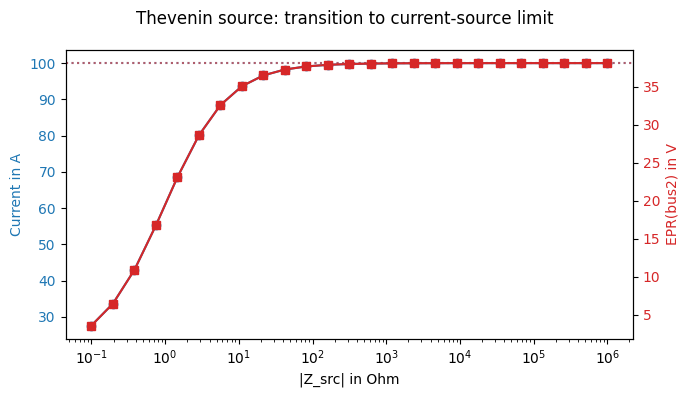

In [5]:
z_values = np.geomspace(0.1, 1e6, 25)
i_loop_mag = []
epr_b2 = []

for z in z_values:
    Z_src = complex(z, 0.0)
    U = 100.0 * Z_src  # keep open-circuit Norton current at 100 A
    net_z = build_two_bus_network(f"net_z_{z:.3g}")
    gi.create_voltage_source(
        name="src",
        bus="bus1",
        voltage={50: U},
        source_impedance={50: Z_src},
        network=net_z,
    )
    net_z.define_paths()
    gi.run_fault(net_z, fault_name="fault1")
    en = net_z.electrical_network
    v_src = en.u_vectors[50][en.bus_indices["bus1"]]
    v_fault = en.u_vectors[50][en.bus_indices["bus2"]]
    I_loop = (U - (v_src - v_fault)) / Z_src
    i_loop_mag.append(abs(I_loop))
    epr_b2.append(epr(net_z, "bus2"))

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.set_xscale("log")
ax1.plot(z_values, i_loop_mag, "o-", color="tab:blue", label="|I_loop|")
ax1.axhline(100.0, color="tab:blue", linestyle=":", alpha=0.6, label="|I_N| (Norton)")
ax1.set_xlabel("|Z_src| in Ohm")
ax1.set_ylabel("Current in A", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(z_values, epr_b2, "s-", color="tab:red", label="EPR(bus2)")
ax2.axhline(epr_i_b2, color="tab:red", linestyle=":", alpha=0.6, label="EPR (current source)")
ax2.set_ylabel("EPR(bus2) in V", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle("Thevenin source: transition to current-source limit")
fig.tight_layout()
plt.show()


## Take-aways

* Default behaviour of `gi.create_source` is unchanged: stationary studies keep using ideal current sources, which is consistent with established grounding-engineering practice.
* `gi.create_voltage_source` is the entry point for Thevenin-style sources whenever the loading of the source by the grounding network matters -- in particular for transient simulations to come.
* In the limit `Z_src -> infinity` (with `U = I_src * Z_src` held constant) the Thevenin formulation recovers the current-source result, which provides a direct numerical sanity check between the two modes.